In [1]:
# CELL 1 — Verify all libraries are available
import sys
print(f"Python version: {sys.version}")

libraries = ["pandas", "numpy", "matplotlib", "seaborn", "sklearn", "joblib", "micromlgen"]
for lib in libraries:
    try:
        __import__(lib)
        print(f"  ✅ {lib} is installed")
    except ImportError:
        print(f"  ❌ {lib} is MISSING — run: pip install {lib}")


Python version: 3.12.3 (main, Jan 22 2026, 20:57:42) [GCC 13.3.0]


  ✅ pandas is installed
  ✅ numpy is installed


  ✅ matplotlib is installed


  ✅ seaborn is installed
  ✅ sklearn is installed
  ✅ joblib is installed


  ✅ micromlgen is installed


In [2]:
# CELL 2 — Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
import joblib

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [3]:
# CELL 3 — Load the LIGTAS voltage dataset (v7.0 — 2-Class: Safe / Dangerous)
df = pd.read_csv("ligtas_voltage_dataset.csv")

print("=== DATASET LOADED (v7.0) ===")
print(f"Shape         : {df.shape}")
print(f"Columns       : {list(df.columns)}")
print(f"Voltage range : {df['voltage_v'].min():.2f} V  to  {df['voltage_v'].max():.2f} V")
print(f"Sensor rated  : 0 - 250 V  (ZMPT101B)")
print(f"Sampling rate : 500ms per reading")
print("\nLabel distribution:")
print(df['status'].value_counts())
print("\nSpike samples (>=30V labeled Safe):")
spikes = df[(df['voltage_v'] >= 30) & (df['label'] == 0)]
print(f"  Count : {len(spikes)}")
print("\nFirst 10 rows:")
display(df.head(10))


=== DATASET LOADED (v7.0) ===
Shape         : (21095, 11)
Columns       : ['voltage_v', 'voltage_squared', 'coverage_area_m2', 'voltage_class', 'danger_score', 'sensor_noise_level', 'dv_dt', 'rolling_mean_5', 'consec_above_30', 'label', 'status']
Voltage range : 0.00 V  to  250.00 V
Sensor rated  : 0 - 250 V  (ZMPT101B)
Sampling rate : 500ms per reading

Label distribution:
status
Dangerous    14254
Safe          6841
Name: count, dtype: int64

Spike samples (>=30V labeled Safe):
  Count : 1934

First 10 rows:


,voltage_v,voltage_squared,coverage_area_m2,voltage_class,danger_score,sensor_noise_level,dv_dt,rolling_mean_5,consec_above_30,label,status
0,26.605836,707.870504,51.676847,2.0,5.359567,0.532117,-0.268092,26.055987,0.0,0,Safe
1,38.143002,1454.888633,106.211598,3.0,6.721466,0.762860,24.168496,18.808205,1.0,1,Dangerous
2,43.227481,1868.615154,136.414979,3.0,7.298234,0.864550,-3.312663,44.880189,5.0,1,Dangerous
3,93.526163,8747.143140,638.569876,3.0,12.535682,1.870523,86.010863,24.751714,1.0,0,Safe
4,31.320041,980.944968,71.612171,3.0,5.926065,0.626401,-0.548905,30.870892,9.0,1,Dangerous
5,212.121661,44995.599136,3284.824967,4.0,23.316804,4.242433,-0.244042,212.539300,12.0,1,Dangerous
6,161.220337,25991.997109,1897.500260,4.0,18.858784,3.224407,138.419296,50.484900,1.0,1,Dangerous
7,38.751418,1501.672390,109.626965,3.0,6.791151,0.775028,1.159913,39.272383,11.0,1,Dangerous
8,91.999246,8463.861270,617.889379,3.0,12.385589,1.839985,81.762630,26.589142,1.0,1,Dangerous
9,16.849630,283.910048,20.726356,1.0,4.131304,0.336993,0.242626,17.675542,0.0,0,Safe


In [4]:
# CELL 4 — Design decisions and formula documentation (v7.0)
#
# ┌─────────────────────────────────────────────────────────────────┐
# │  SENSOR RANGE: 0 - 250V  (ZMPT101B rated range)                 │
# │  Use case: AC leakage from downed pole / transformer secondary   │
# │  spreading into flood water.                                     │
# │  Sampling interval: 500ms                                        │
# ├─────────────────────────────────────────────────────────────────┤
# │  CLASSIFICATION (v7.0 — 2 Classes):                             │
# │    0.00 –  5.00 V  →  Dead Zone (clamped to Safe, no ML)        │
# │    5.01 – 250  V   →  ML decision (all cases, no hard threshold) │
# │                                                                  │
# │  Hard threshold at 30V REMOVED in v7.0.                         │
# │  ML now handles all voltage decisions above the dead zone.      │
# ├─────────────────────────────────────────────────────────────────┤
# │  SPIKE REJECTION (v7.0):                                         │
# │  Real sensor spikes = brief high readings (1-2 samples, 0.5-1s) │
# │  Real AC leakage   = sustained high readings (3+ samples)        │
# │                                                                  │
# │  Three new temporal features distinguish them:                  │
# │    dv_dt           — voltage jump from previous sample           │
# │                      Spike: very high | Leakage: gradual         │
# │    rolling_mean_5  — average of last 5 readings (2.5s window)   │
# │                      Spike: still low | Leakage: sustained high  │
# │    consec_above_30 — consecutive readings >= 30V                 │
# │                      Spike: 1-2      | Leakage: 3+              │
# ├─────────────────────────────────────────────────────────────────┤
# │  COVERAGE AREA FORMULA — ESD Flood Water Surface Spread          │
# │  hazard_radius (m)  = V / 6.56                                   │
# │  coverage_area (m2) = pi x (V / 6.56)^2                          │
# │  Basis: Rifkin & Shafer (2008) Electric Shock Drowning Study     │
# │  US Coast Guard — lethal gradient = 6.56 V/m (2 V/ft)           │
# └─────────────────────────────────────────────────────────────────┘


In [5]:
# CELL 5 — Data exploration
print("=== DATASET SUMMARY ===")
display(df.describe())

print("\n=== CLASS DISTRIBUTION ===")
print(df['status'].value_counts())

print("\n=== TEMPORAL FEATURES — Spike vs Dangerous ===")
spikes  = df[(df['voltage_v'] >= 30) & (df['label'] == 0)]
danger  = df[df['label'] == 1]

print("\nSpike rows (>=30V, Safe):")
print(spikes[['voltage_v','dv_dt','rolling_mean_5','consec_above_30']].describe().round(2))

print("\nDangerous rows:")
print(danger[['voltage_v','dv_dt','rolling_mean_5','consec_above_30']].describe().round(2))


=== DATASET SUMMARY ===


,voltage_v,voltage_squared,coverage_area_m2,voltage_class,danger_score,sensor_noise_level,dv_dt,rolling_mean_5,consec_above_30,label
count,21095.000000,21095.000000,21095.000000,21095.000000,21095.000000,21095.000000,21095.000000,21095.000000,21095.000000,21095.000000
mean,87.398269,12568.887156,917.569610,2.859872,11.431757,1.747965,9.508580,72.557554,4.995686,0.675705
std,70.218683,16795.437297,1226.121506,1.160770,6.923184,1.404374,31.317869,65.346807,4.932168,0.468122
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-9.941990,0.000000,0.000000,0.000000
25%,31.658179,1002.240288,73.166798,3.000000,5.966131,0.633164,-1.362411,25.199860,1.000000,0.000000
50%,65.054010,4232.024178,308.951519,3.000000,9.657066,1.301080,0.356207,45.328102,4.000000,1.000000
75%,132.822215,17641.740853,1287.904416,4.000000,16.274145,2.656444,2.744054,101.728704,8.000000,1.000000
max,250.000000,62500.000000,4562.703117,4.000000,26.522695,5.000000,236.120629,249.443470,19.000000,1.000000



=== CLASS DISTRIBUTION ===
status
Dangerous    14254
Safe          6841
Name: count, dtype: int64

=== TEMPORAL FEATURES — Spike vs Dangerous ===

Spike rows (>=30V, Safe):
       voltage_v    dv_dt  rolling_mean_5  consec_above_30
count    1934.00  1934.00         1934.00          1934.00
mean       74.01    44.45           30.61             1.22
std        25.83    33.70            9.78             0.42
min        30.04     0.00           10.86             1.00
25%        52.17    12.15           23.79             1.00
50%        73.25    44.03           29.57             1.00
75%        96.42    73.74           36.13             1.00
max       119.90   115.09           64.15             2.00

Dangerous rows:
       voltage_v     dv_dt  rolling_mean_5  consec_above_30
count   14254.00  14254.00        14254.00         14254.00
mean      114.10      8.04           98.03             7.23
std        68.17     33.12           65.27             4.53
min        30.00     -9.94           1

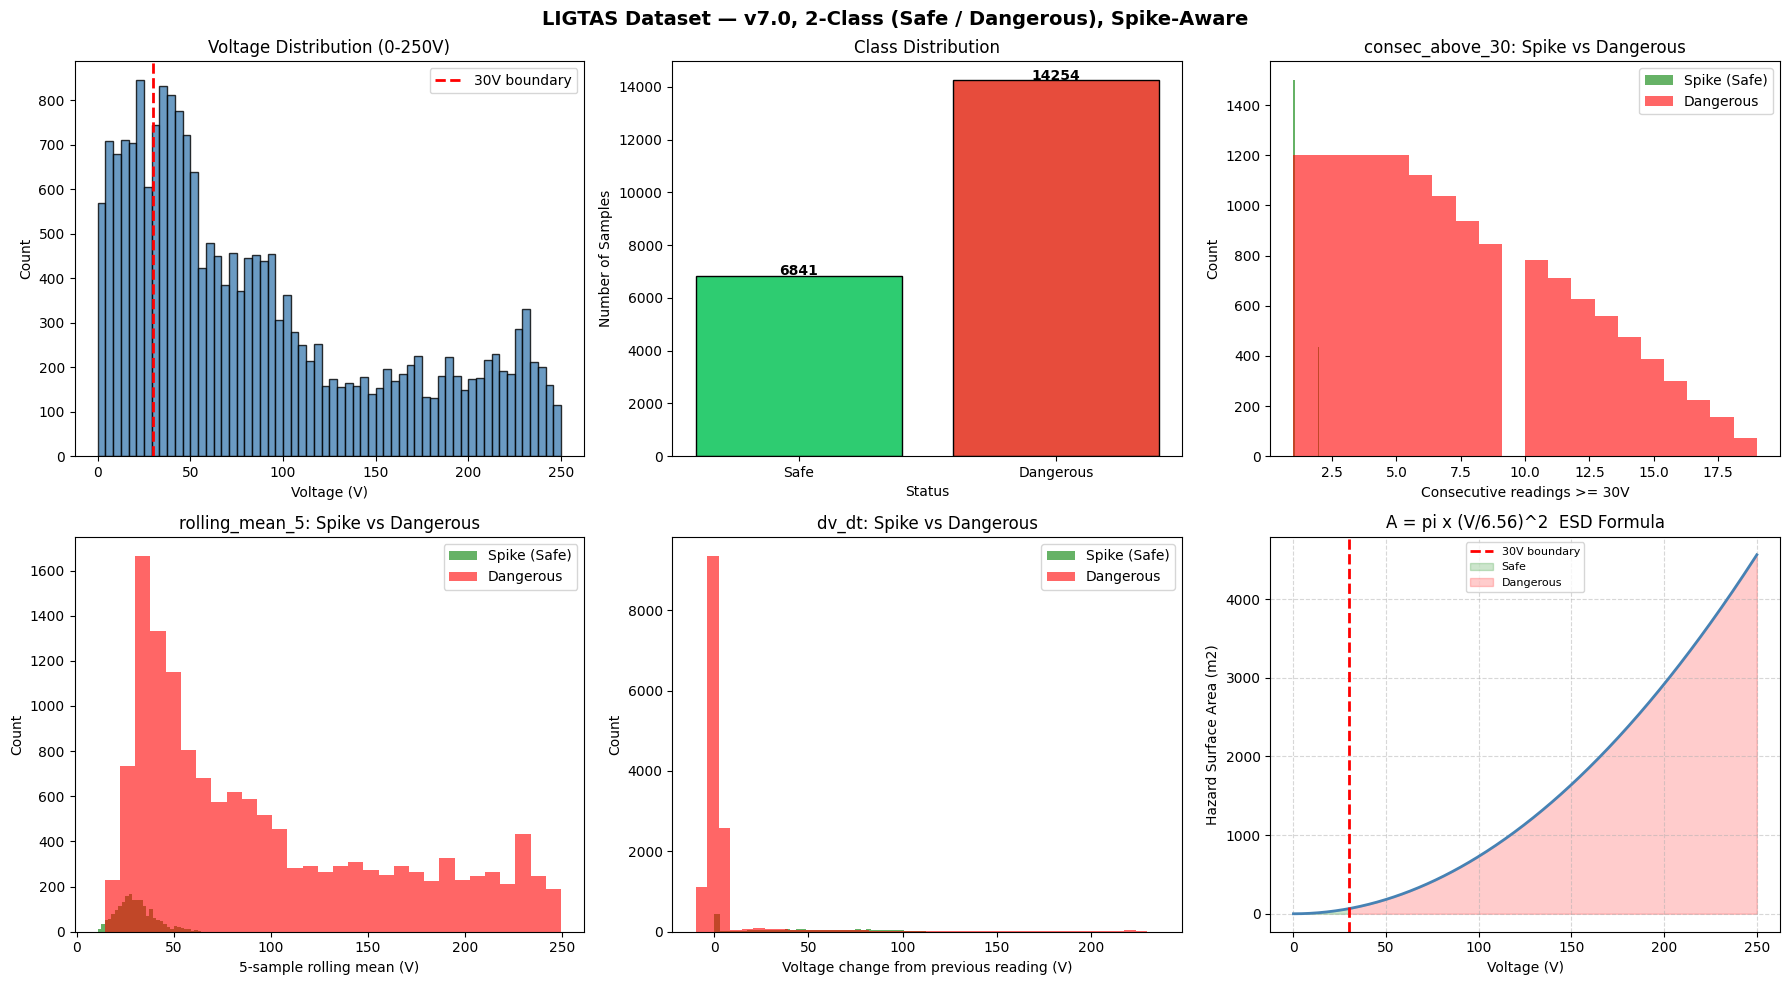

✅ Chart saved as ligtas_overview.png


In [6]:
# CELL 6 — Data visualization (v7.0 — 2-Class + Temporal Features)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("LIGTAS Dataset — v7.0, 2-Class (Safe / Dangerous), Spike-Aware", fontsize=14, fontweight="bold")

ESD_GRADIENT = 6.56

# Plot 1: Voltage distribution
axes[0,0].hist(df["voltage_v"], bins=60, color="steelblue", edgecolor="black", alpha=0.8)
axes[0,0].axvline(x=30, color="red", linestyle="--", linewidth=2, label="30V boundary")
axes[0,0].set_title("Voltage Distribution (0-250V)")
axes[0,0].set_xlabel("Voltage (V)")
axes[0,0].set_ylabel("Count")
axes[0,0].legend()

# Plot 2: Class distribution
colors = ["#2ecc71", "#e74c3c"]
counts = df["status"].value_counts().reindex(["Safe", "Dangerous"])
axes[0,1].bar(counts.index, counts.values, color=colors, edgecolor="black")
axes[0,1].set_title("Class Distribution")
axes[0,1].set_xlabel("Status")
axes[0,1].set_ylabel("Number of Samples")
for i, v in enumerate(counts.values):
    axes[0,1].text(i, v + 20, str(v), ha="center", fontweight="bold")

# Plot 3: consec_above_30 — Spike vs Dangerous
spikes = df[(df['voltage_v'] >= 30) & (df['label'] == 0)]
danger = df[df['label'] == 1]
axes[0,2].hist(spikes['consec_above_30'], bins=20, color='green',  alpha=0.6, label='Spike (Safe)')
axes[0,2].hist(danger['consec_above_30'], bins=20, color='red',    alpha=0.6, label='Dangerous')
axes[0,2].set_title("consec_above_30: Spike vs Dangerous")
axes[0,2].set_xlabel("Consecutive readings >= 30V")
axes[0,2].set_ylabel("Count")
axes[0,2].legend()

# Plot 4: rolling_mean_5 — Spike vs Dangerous
axes[1,0].hist(spikes['rolling_mean_5'], bins=30, color='green', alpha=0.6, label='Spike (Safe)')
axes[1,0].hist(danger['rolling_mean_5'], bins=30, color='red',   alpha=0.6, label='Dangerous')
axes[1,0].set_title("rolling_mean_5: Spike vs Dangerous")
axes[1,0].set_xlabel("5-sample rolling mean (V)")
axes[1,0].set_ylabel("Count")
axes[1,0].legend()

# Plot 5: dv_dt — Spike vs Dangerous
axes[1,1].hist(spikes['dv_dt'], bins=40, color='green', alpha=0.6, label='Spike (Safe)')
axes[1,1].hist(danger['dv_dt'], bins=40, color='red',   alpha=0.6, label='Dangerous')
axes[1,1].set_title("dv_dt: Spike vs Dangerous")
axes[1,1].set_xlabel("Voltage change from previous reading (V)")
axes[1,1].set_ylabel("Count")
axes[1,1].legend()

# Plot 6: ESD coverage area curve
v_line = np.linspace(0, 250, 500)
a_line = np.pi * (v_line / ESD_GRADIENT) ** 2
axes[1,2].plot(v_line, a_line, color="steelblue", linewidth=2)
axes[1,2].axvline(x=30, color="red", linestyle="--", linewidth=2, label="30V boundary")
axes[1,2].fill_between(v_line, a_line, where=(v_line < 30), color="green", alpha=0.2, label="Safe")
axes[1,2].fill_between(v_line, a_line, where=(v_line >= 30), color="red", alpha=0.2, label="Dangerous")
axes[1,2].set_title("A = pi x (V/6.56)^2  ESD Formula")
axes[1,2].set_xlabel("Voltage (V)")
axes[1,2].set_ylabel("Hazard Surface Area (m2)")
axes[1,2].legend(fontsize=8)
axes[1,2].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("ligtas_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved as ligtas_overview.png")


In [7]:
# CELL 7 — Prepare features (X) and labels (y)  [v7.0 — 9 Features]
#
# 9 features:
#  Feature              Reason
#  ───────────────────  ──────────────────────────────────────────────────
#  voltage_v            Raw sensor reading (dead zone clamped to 0 if <=5V)
#  voltage_squared      V^2 — energy scales with square of voltage
#  coverage_area_m2     pi x (V/6.56)^2 — ESD flood water surface spread
#  voltage_class        0-4 intensity zone category
#  danger_score         V / (1 + log(area+1)) — combined risk index
#  sensor_noise_level   Estimated ZMPT101B noise (2% of reading)
#  dv_dt                Change from previous reading — spike detector
#  rolling_mean_5       Average of last 5 readings (2.5s window)
#  consec_above_30      Consecutive readings >= 30V — sustained vs spike
#
# Label rules (v7.0 — 2 classes):
#   0 = Safe      — voltage < 30V, OR a brief spike (1-2 samples)
#   1 = Dangerous — voltage >= 30V sustained (3+ consecutive samples)

FEATURES = [
    'voltage_v', 'voltage_squared', 'coverage_area_m2',
    'voltage_class', 'danger_score', 'sensor_noise_level',
    'dv_dt', 'rolling_mean_5', 'consec_above_30'
]
X = df[FEATURES]
y = df['label']

print(f"Features : {list(X.columns)}")
print(f"Samples  : {len(X)}")
print(f"\nClass distribution:")
for lbl, name in [(0, "Safe"), (1, "Dangerous")]:
    count = (y == lbl).sum()
    pct   = count / len(y) * 100
    print(f"  {name:<10}: {count:,}  ({pct:.1f}%)")


Features : ['voltage_v', 'voltage_squared', 'coverage_area_m2', 'voltage_class', 'danger_score', 'sensor_noise_level', 'dv_dt', 'rolling_mean_5', 'consec_above_30']
Samples  : 21095

Class distribution:
  Safe      : 6,841  (32.4%)
  Dangerous : 14,254  (67.6%)


In [8]:
# CELL 8 — Train/Test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("=== TRAIN / TEST SPLIT ===")
print(f"  Training: {len(X_train):,}  (80%)")
print(f"  Testing : {len(X_test):,}  (20%)")
print("\nTrain distribution:")
for lbl, name in [(0, "Safe"), (1, "Dangerous")]:
    print(f"  {name:<10}: {(y_train==lbl).sum():,}")
print("\nTest distribution:")
for lbl, name in [(0, "Safe"), (1, "Dangerous")]:
    print(f"  {name:<10}: {(y_test==lbl).sum():,}")


=== TRAIN / TEST SPLIT ===
  Training: 16,876  (80%)
  Testing : 4,219  (20%)

Train distribution:
  Safe      : 5,473
  Dangerous : 11,403

Test distribution:
  Safe      : 1,368
  Dangerous : 2,851


In [9]:
# CELL 9 — Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Features scaled (9 features)")
print("\nScaler means:")
for col, mean in zip(X.columns, scaler.mean_):
    print(f"  {col:<25}: {mean:.6f}")
print("\nScaler scales:")
for col, scale in zip(X.columns, scaler.scale_):
    print(f"  {col:<25}: {scale:.6f}")


✅ Features scaled (9 features)

Scaler means:
  voltage_v                : 87.236891
  voltage_squared          : 12524.263352
  coverage_area_m2         : 914.311927
  voltage_class            : 2.858557
  danger_score             : 11.416161
  sensor_noise_level       : 1.744738
  dv_dt                    : 9.331306
  rolling_mean_5           : 72.518186
  consec_above_30          : 4.974994

Scaler scales:
  voltage_v                : 70.099844
  voltage_squared          : 16763.105686
  coverage_area_m2         : 1223.761193
  voltage_class            : 1.159209
  danger_score             : 6.913384
  sensor_noise_level       : 1.401997
  dv_dt                    : 30.771785
  rolling_mean_5           : 65.399814
  consec_above_30          : 4.907424


In [10]:
# CELL 10 — Train Random Forest model (v7.0 — 2-Class, 9 Features)
print("Training Random Forest (100 trees, 9 features, 2 classes)...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)
rf_model.fit(X_train_scaled, y_train)

print("✅ Random Forest training complete!")
print(f"   Trees    : {rf_model.n_estimators}")
print(f"   Features : {rf_model.n_features_in_}")
print(f"   Classes  : {list(rf_model.classes_)}  (0=Safe, 1=Dangerous)")

importances = rf_model.feature_importances_
print("\n=== FEATURE IMPORTANCE ===")
for name, imp in sorted(zip(X.columns, importances), key=lambda x: -x[1]):
    bar = "█" * int(imp * 60)
    print(f"  {name:<25}: {imp:.4f}  {bar}")


Training Random Forest (100 trees, 9 features, 2 classes)...


✅ Random Forest training complete!
   Trees    : 100
   Features : 9
   Classes  : [np.int64(0), np.int64(1)]  (0=Safe, 1=Dangerous)

=== FEATURE IMPORTANCE ===
  consec_above_30          : 0.3062  ██████████████████
  rolling_mean_5           : 0.2408  ██████████████
  dv_dt                    : 0.0943  █████
  voltage_squared          : 0.0878  █████
  voltage_v                : 0.0780  ████
  sensor_noise_level       : 0.0750  ████
  coverage_area_m2         : 0.0569  ███
  danger_score             : 0.0423  ██
  voltage_class            : 0.0187  █


In [11]:
# CELL 11 — Evaluate Random Forest model
rf_pred = rf_model.predict(X_test_scaled)

rf_acc  = accuracy_score(y_test,  rf_pred)
rf_prec = precision_score(y_test, rf_pred, average="weighted", zero_division=0)
rf_rec  = recall_score(y_test,    rf_pred, average="weighted", zero_division=0)
rf_f1   = f1_score(y_test,        rf_pred, average="weighted", zero_division=0)

print("=" * 55)
print("  MODEL: Random Forest — 9 features, 2-Class (v7.0)")
print("=" * 55)
print(f"  Accuracy   : {rf_acc:.4f}  ({rf_acc*100:.2f}%)")
print(f"  Precision  : {rf_prec:.4f}")
print(f"  Recall     : {rf_rec:.4f}")
print(f"  F1-Score   : {rf_f1:.4f}")
print(f"\nDetailed Report:")
print(classification_report(y_test, rf_pred,
      target_names=["Safe (0)", "Dangerous (1)"]))

# Spike-specific accuracy
test_df = X_test.copy()
test_df['label'] = y_test.values
test_df['pred']  = rf_pred
spikes_test      = test_df[(test_df['voltage_v'] >= 30) & (test_df['label'] == 0)]
spike_correct    = (spikes_test['pred'] == 0).sum()
print(f"Spike accuracy (>=30V but Safe): {spike_correct}/{len(spikes_test)} = {spike_correct/len(spikes_test)*100:.1f}%")


  MODEL: Random Forest — 9 features, 2-Class (v7.0)
  Accuracy   : 0.9654  (96.54%)
  Precision  : 0.9654
  Recall     : 0.9654
  F1-Score   : 0.9654

Detailed Report:
               precision    recall  f1-score   support

     Safe (0)       0.94      0.95      0.95      1368
Dangerous (1)       0.98      0.97      0.97      2851

     accuracy                           0.97      4219
    macro avg       0.96      0.96      0.96      4219
 weighted avg       0.97      0.97      0.97      4219

Spike accuracy (>=30V but Safe): 317/387 = 81.9%


/tmp/ipykernel_149/3695632620.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(metrics, color="#e5e7eb", fontsize=12, fontweight="bold")


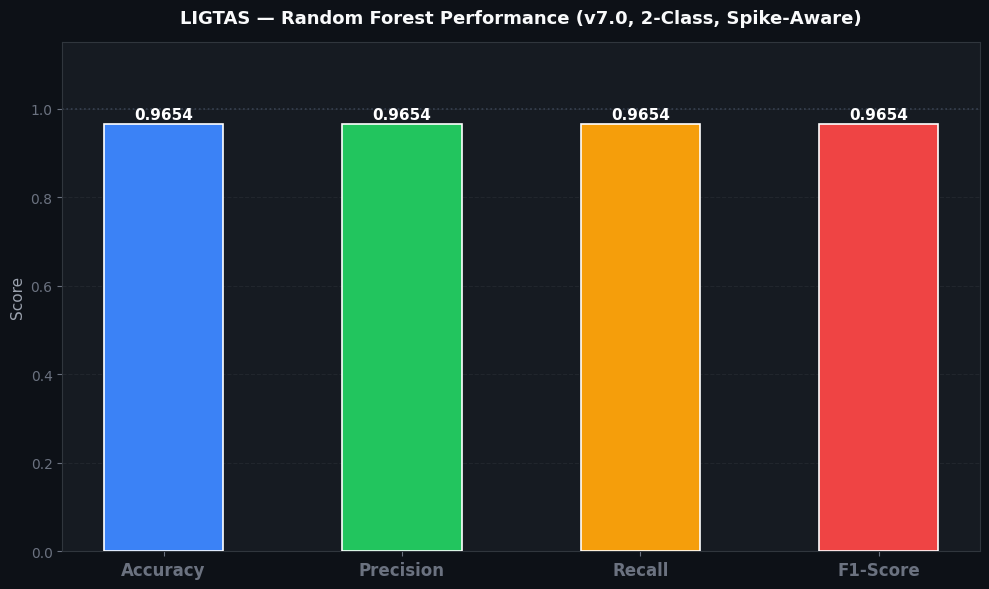

✅ Metrics chart saved as model_metrics.png


In [12]:
# CELL 12 — Model Metrics Chart
metrics   = ["Accuracy", "Precision", "Recall", "F1-Score"]
rf_scores = [rf_acc, rf_prec, rf_rec, rf_f1]
bar_colors = ["#3b82f6", "#22c55e", "#f59e0b", "#ef4444"]

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("#0d1117")
ax.set_facecolor("#161b22")

bars = ax.bar(metrics, rf_scores, color=bar_colors, edgecolor="white",
              linewidth=1.2, width=0.5, zorder=3)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
            f"{h:.4f}", ha="center", va="bottom",
            fontsize=11, color="white", fontweight="bold")

ax.set_ylim(0, 1.15)
ax.set_xticklabels(metrics, color="#e5e7eb", fontsize=12, fontweight="bold")
ax.set_ylabel("Score", color="#9ca3af", fontsize=11)
ax.set_title("LIGTAS — Random Forest Performance (v7.0, 2-Class, Spike-Aware)",
             color="#f9fafb", fontsize=13, fontweight="bold", pad=14)
ax.tick_params(colors="#6b7280")
for spine in ax.spines.values(): spine.set_color("#30363d")
ax.set_yticks([0.0,0.2,0.4,0.6,0.8,1.0])
ax.set_yticklabels(["0.0","0.2","0.4","0.6","0.8","1.0"], color="#6b7280")
ax.axhline(y=1.0, color="#374151", linestyle=":", linewidth=1.2, zorder=2)
ax.grid(axis="y", color="#21262d", linewidth=0.8, linestyle="--", zorder=1)

plt.tight_layout()
plt.savefig("model_metrics.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()
print("✅ Metrics chart saved as model_metrics.png")


Per-class summary:
  Safe      : TP=1298  TN=2775  FP=76  FN=70
  Dangerous : TP=2775  TN=1298  FP=70  FN=76


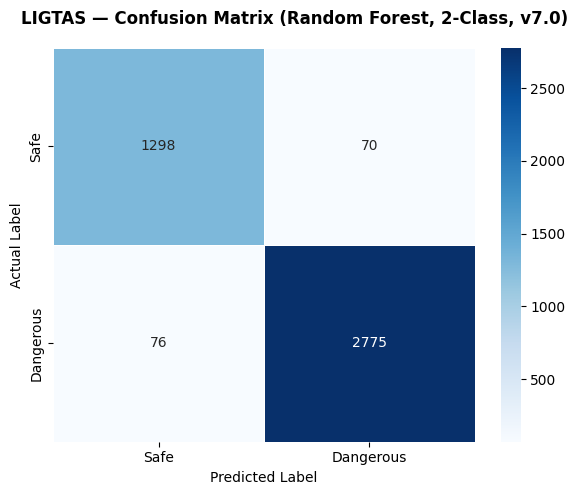

✅ Confusion matrix saved as confusion_matrix.png


In [13]:
# CELL 13 — Confusion Matrix (2-Class)
fig, ax = plt.subplots(figsize=(6, 5))
fig.suptitle("LIGTAS — Confusion Matrix (Random Forest, 2-Class, v7.0)",
             fontsize=12, fontweight="bold")

cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Safe", "Dangerous"],
            yticklabels=["Safe", "Dangerous"],
            linewidths=0.5)
ax.set_xlabel("Predicted Label", fontsize=10)
ax.set_ylabel("Actual Label",    fontsize=10)

print("Per-class summary:")
for i, cls in enumerate(["Safe", "Dangerous"]):
    tp = cm[i,i]
    fp = cm[:,i].sum() - tp
    fn = cm[i,:].sum() - tp
    tn = cm.sum() - tp - fp - fn
    print(f"  {cls:<10}: TP={tp}  TN={tn}  FP={fp}  FN={fn}")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Confusion matrix saved as confusion_matrix.png")


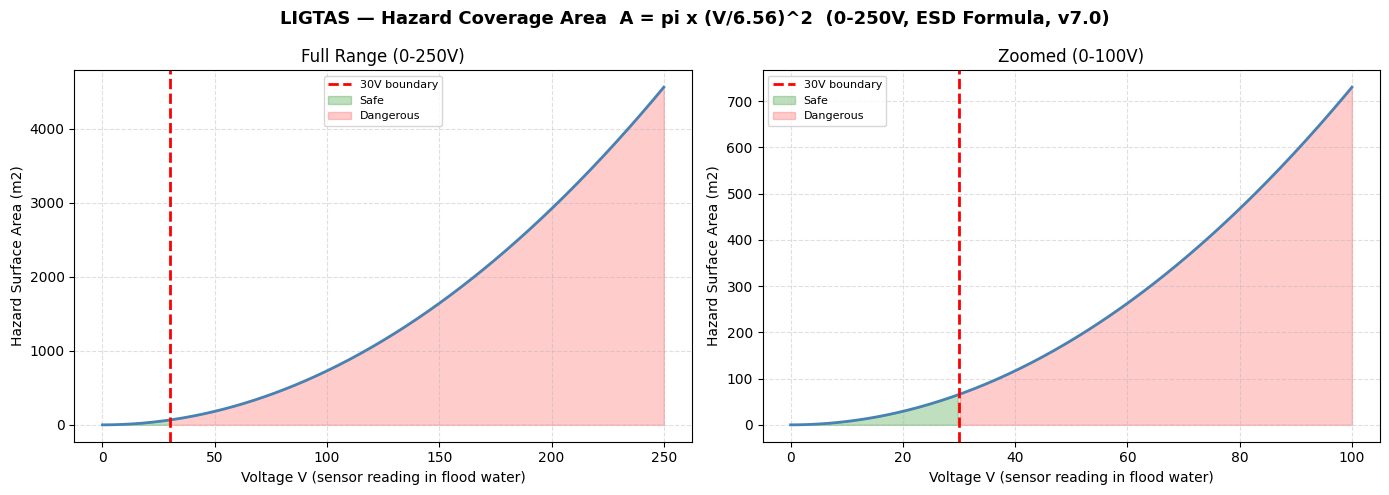

✅ Coverage curve saved as coverage_area_curve.png

Sample values (ZMPT101B 0-250V range):
  V=   1V  radius=0.15m  area=    0.07 m2  [Safe]
  V=   5V  radius=0.76m  area=    1.83 m2  [Safe]
  V=  10V  radius=1.52m  area=    7.30 m2  [Safe]
  V=  20V  radius=3.05m  area=   29.20 m2  [Safe]
  V=  29V  radius=4.42m  area=   61.40 m2  [Safe]
  V=  30V  radius=4.57m  area=   65.70 m2  [Dangerous]
  V=  50V  radius=7.62m  area=  182.51 m2  [Dangerous]
  V= 100V  radius=15.24m  area=  730.03 m2  [Dangerous]
  V= 220V  radius=33.54m  area= 3533.36 m2  [Dangerous]
  V= 250V  radius=38.11m  area= 4562.70 m2  [Dangerous]


In [14]:
# CELL 14 — Coverage Area Curve (ESD Flood Water Formula, 0-250V)
# Formula: A = pi x (V / 6.56)^2
# Basis  : Rifkin & Shafer (2008) Electric Shock Drowning Study
#          US Coast Guard — lethal gradient = 6.56 V/m (2 V/ft)
# Ref    : https://en.wikipedia.org/wiki/Electric_shock_drowning

ESD_GRADIENT = 6.56
# Use smooth linspace — v7 dataset is event-based, not a voltage sweep
v_full   = np.linspace(0, 250, 500)
a_full   = np.pi * (v_full / ESD_GRADIENT) ** 2
v_zoom   = np.linspace(0, 100, 300)
a_zoom   = np.pi * (v_zoom / ESD_GRADIENT) ** 2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "LIGTAS — Hazard Coverage Area  A = pi x (V/6.56)^2  (0-250V, ESD Formula, v7.0)",
    fontsize=13, fontweight="bold"
)

for ax, (title, v_line, a_line) in zip(axes, [
    ("Full Range (0-250V)", v_full, a_full),
    ("Zoomed (0-100V)",     v_zoom, a_zoom)
]):
    ax.plot(v_line, a_line, color="steelblue", linewidth=2)
    ax.axvline(x=30, color="red", linestyle="--", linewidth=2, label="30V boundary")
    ax.fill_between(v_line, a_line, where=(v_line < 30),  color="green", alpha=0.25, label="Safe")
    ax.fill_between(v_line, a_line, where=(v_line >= 30), color="red",   alpha=0.2,  label="Dangerous")
    ax.set_title(title)
    ax.set_xlabel("Voltage V (sensor reading in flood water)")
    ax.set_ylabel("Hazard Surface Area (m2)")
    ax.legend(fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("coverage_area_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Coverage curve saved as coverage_area_curve.png")
print()
print("Sample values (ZMPT101B 0-250V range):")
for v in [1, 5, 10, 20, 29, 30, 50, 100, 220, 250]:
    r   = v / ESD_GRADIENT
    a   = np.pi * r * r
    lbl = "Safe" if v < 30 else "Dangerous"
    print(f"  V={v:>4}V  radius={r:.2f}m  area={a:>8.2f} m2  [{lbl}]")


In [15]:
# CELL 15 — Save trained model and scaler
joblib.dump(rf_model, "ligtas_rf_model.pkl")
joblib.dump(scaler,   "ligtas_scaler.pkl")
print("✅ Saved:")
print("   ligtas_rf_model.pkl — Random Forest (2-Class, 9 features)")
print("   ligtas_scaler.pkl   — StandardScaler (9 features)")


✅ Saved:
   ligtas_rf_model.pkl — Random Forest (2-Class, 9 features)
   ligtas_scaler.pkl   — StandardScaler (9 features)


In [16]:
# CELL 16 — Real-time prediction function (v7.0 — 2-Class, Spike-Aware)
#
# Mirrors ligtas_ml.h exactly. Call once every 500ms.

ESD_GRADIENT = 6.56
DEAD_ZONE_V  = 5.0
ROLLING_N    = 5

# Temporal state — persists across calls
_state = {'prev_v': 0.0, 'window': [0.0]*ROLLING_N, 'consec': 0}

def ligtas_predict(voltage_value):
    voltage_value = min(max(voltage_value, 0.0), 250.0)

    # Update temporal state
    dv_dt = voltage_value - _state['prev_v']
    _state['prev_v'] = voltage_value
    _state['window'] = _state['window'][1:] + [voltage_value]
    rolling_mean = float(np.mean(_state['window']))
    _state['consec'] = (_state['consec'] + 1) if voltage_value >= 30.0 else 0

    # Dead zone — return Safe immediately
    if voltage_value <= DEAD_ZONE_V:
        return {'prediction': 0, 'status': 'Safe',
                'hazard_radius': 0.0, 'coverage_area': 0.0}

    # Compute features
    v_sq         = voltage_value ** 2
    radius       = voltage_value / ESD_GRADIENT
    area         = np.pi * radius ** 2
    vc           = (0 if voltage_value < 5  else
                    1 if voltage_value < 26 else
                    2 if voltage_value < 30 else
                    3 if voltage_value < 100 else 4)
    danger_score = voltage_value / (1.0 + np.log(area + 1.0))
    noise_level  = voltage_value * 0.02

    features = [[voltage_value, v_sq, area, vc, danger_score,
                 noise_level, dv_dt, rolling_mean, float(_state['consec'])]]
    final_pred = rf_model.predict(scaler.transform(features))[0]

    labels = ['Safe', 'Dangerous']
    return {'prediction': final_pred, 'status': labels[final_pred],
            'hazard_radius': radius, 'coverage_area': area}

def ligtas_reset():
    _state['prev_v'] = 0.0
    _state['window'] = [0.0] * ROLLING_N
    _state['consec'] = 0

# ── Test: voltage range sweep ─────────────────────────────────
ligtas_reset()
print("=== VOLTAGE RANGE TEST ===")
for v in [0.0, 2.5, 5.0, 5.1, 10.0, 20.0, 25.0, 29.9, 30.0, 35.0, 100.0, 220.0, 250.0]:
    res  = ligtas_predict(v)
    icon = {"Safe": "🟢", "Dangerous": "🔴"}[res["status"]]
    print(f"  {v:6.1f}V → {icon} {res['status']}")

# ── Spike test: brief spike then drops back ───────────────────
ligtas_reset()
print("\n=== SPIKE TEST (1-sample spike at 80V) ===")
sequence = [(5.0, "baseline"), (5.0, "baseline"), (80.0, "SPIKE"), (5.0, "back to 5V"), (5.0, "back to 5V")]
for reading, label in sequence:
    res  = ligtas_predict(reading)
    icon = {"Safe": "🟢", "Dangerous": "🔴"}[res["status"]]
    print(f"  {reading:6.1f}V ({label:<15}) → {icon} {res['status']}")

# ── Sustained leakage test ────────────────────────────────────
ligtas_reset()
print("\n=== SUSTAINED LEAKAGE TEST (real danger) ===")
sequence = [(5.0, "baseline"), (35.0, "leakage 1"), (35.0, "leakage 2"),
            (35.0, "leakage 3"), (35.0, "leakage 4"), (35.0, "leakage 5")]
for reading, label in sequence:
    res  = ligtas_predict(reading)
    icon = {"Safe": "🟢", "Dangerous": "🔴"}[res["status"]]
    print(f"  {reading:6.1f}V ({label:<15}) → {icon} {res['status']}")


=== VOLTAGE RANGE TEST ===
     0.0V → 🟢 Safe
     2.5V → 🟢 Safe
     5.0V → 🟢 Safe
     5.1V → 🟢 Safe
    10.0V → 🟢 Safe
    20.0V → 🟢 Safe
    25.0V → 🟢 Safe
    29.9V → 🟢 Safe
    30.0V → 🔴 Dangerous
    35.0V → 🔴 Dangerous
   100.0V → 🔴 Dangerous
   220.0V → 🔴 Dangerous
   250.0V → 🔴 Dangerous

=== SPIKE TEST (1-sample spike at 80V) ===
     5.0V (baseline       ) → 🟢 Safe
     5.0V (baseline       ) → 🟢 Safe
    80.0V (SPIKE          ) → 🟢 Safe
     5.0V (back to 5V     ) → 🟢 Safe
     5.0V (back to 5V     ) → 🟢 Safe

=== SUSTAINED LEAKAGE TEST (real danger) ===
     5.0V (baseline       ) → 🟢 Safe
    35.0V (leakage 1      ) → 🟢 Safe
    35.0V (leakage 2      ) → 🟢 Safe
    35.0V (leakage 3      ) → 🔴 Dangerous


    35.0V (leakage 4      ) → 🔴 Dangerous
    35.0V (leakage 5      ) → 🔴 Dangerous


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

In [17]:
# CELL 17 — Load saved model without retraining
loaded_model  = joblib.load("ligtas_rf_model.pkl")
loaded_scaler = joblib.load("ligtas_scaler.pkl")
print("✅ Model and scaler loaded!")
print(f"   Features : 9")
print(f"   Classes  : 2  (0=Safe, 1=Dangerous)")
print(f"   Range    : 0-250V  (ZMPT101B)")

ESD_GRADIENT = 6.56

# Quick test — 220V mains leak (sustained, consec=5)
test_v       = 220.0
v_sq         = test_v ** 2
radius       = test_v / ESD_GRADIENT
area         = np.pi * radius * radius
vc           = 4
ds           = test_v / (1.0 + np.log(area + 1.0))
noise        = test_v * 0.02
dv_dt        = test_v - 0.0   # coming from baseline
rolling_mean = (0*4 + test_v) / 5.0
consec       = 5.0             # simulate 5 consecutive readings

result = loaded_model.predict(
    loaded_scaler.transform([[test_v, v_sq, area, vc, ds, noise, dv_dt, rolling_mean, consec]])
)[0]
print(f"\n220V mains leak test (consec=5):")
print(f"  Hazard radius : {radius:.2f} m")
print(f"  Coverage area : {area:.2f} m2")
print(f"  Result        : {['🟢 SAFE', '🔴 DANGEROUS'][result]}")


✅ Model and scaler loaded!
   Features : 9
   Classes  : 2  (0=Safe, 1=Dangerous)
   Range    : 0-250V  (ZMPT101B)

220V mains leak test (consec=5):
  Hazard radius : 33.54 m
  Coverage area : 3533.36 m2
  Result        : 🔴 DANGEROUS


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [18]:
# CELL 18 — Export to Arduino C++ (ligtas_model.h)
import joblib, numpy as np
from micromlgen import port

rf_model = joblib.load("ligtas_rf_model.pkl")
scaler   = joblib.load("ligtas_scaler.pkl")

with open("ligtas_model.h", "w") as f:
    f.write(port(rf_model))
print("✅ ligtas_model.h created!")

means  = ", ".join([f"{m:.6f}f" for m in scaler.mean_])
scales = ", ".join([f"{s:.6f}f" for s in scaler.scale_])
print("\n=== COPY THESE INTO ligtas_ml.h ===")
print(f"const float SCALER_MEAN[9]  = {{{means}}};")
print(f"const float SCALER_SCALE[9] = {{{scales}}};")
print("\n// Feature order [0-8]:")
print("// [0] voltage_v            — raw sensor reading")
print("// [1] voltage_squared      — V^2")
print("// [2] coverage_area_m2     — pi x (V/6.56)^2")
print("// [3] voltage_class        — 0-4 zone")
print("// [4] danger_score         — V / (1 + log(area+1))")
print("// [5] sensor_noise_level   — V x 0.02")
print("// [6] dv_dt                — change from previous reading")
print("// [7] rolling_mean_5       — average of last 5 readings")
print("// [8] consec_above_30      — consecutive readings >= 30V")


✅ ligtas_model.h created!

=== COPY THESE INTO ligtas_ml.h ===
const float SCALER_MEAN[9]  = {87.236891f, 12524.263352f, 914.311927f, 2.858557f, 11.416161f, 1.744738f, 9.331306f, 72.518186f, 4.974994f};
const float SCALER_SCALE[9] = {70.099844f, 16763.105686f, 1223.761193f, 1.159209f, 6.913384f, 1.401997f, 30.771785f, 65.399814f, 4.907424f};

// Feature order [0-8]:
// [0] voltage_v            — raw sensor reading
// [1] voltage_squared      — V^2
// [2] coverage_area_m2     — pi x (V/6.56)^2
// [3] voltage_class        — 0-4 zone
// [4] danger_score         — V / (1 + log(area+1))
// [5] sensor_noise_level   — V x 0.02
// [6] dv_dt                — change from previous reading
// [7] rolling_mean_5       — average of last 5 readings
// [8] consec_above_30      — consecutive readings >= 30V
